In [44]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')

import numpy as np
from datetime import datetime

# # # # # # # # # # # # # # #
save = True
fp_type = 'morgan'
cnts = False
bits = 1024
r = 2
dist_type = 'euclidean'
# # # # # # # # # # # # # # #

today = datetime.today().strftime('%Y%m%d%H')

if cnts==False:
    c = 'bitv'
elif cnts==True:
    c = 'cntv'
    
if dist_type=='euclidean':
    d = 'eucnorm'
    
v = '_'.join(['baseline','2000n_test',fp_type,c,f'{bits}b',f'{r}r',d])
tag = f'{today}_{v}'
print(tag)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


2022050223_baseline_2000n_test_morgan_bitv_1024b_2r_eucnorm


## 1) Get anc-aug map.

In [45]:
rdir = '/home/kat/Repos/SALSA/results/'
mdir = '/home/kat/Repos/SALSA/data/model_ready/'

In [46]:
from eval_functions import *

which_test = '01'
which_train = '01'

anc_path = f'{mdir}{which_test}/test/anchor_smiles.csv'
aug_path = f'{mdir}{which_test}/test/augmented_smiles.csv'   
anc_map = get_anc_map( get_dataset_array(anc_path, aug_path) )

## 2) Load model UMAP for consistent ordering of coords (?) Calculate fps.

In [47]:
# Which evaluation set? ...
# # # # # # # # # # # 
umap_tag = '2022041809_a04_2000n_test_32neigh_mindist0pt1'
# # # # # # # # # # # 

import pandas as pd
from utilities.fp_utils import get_fps_in_parallel
import numpy as np
from sklearn import preprocessing

df = pd.read_csv(f'{rdir}umap_dfs/{umap_tag}.csv', usecols=["Smiles","Label","Atype"])
display(df)

fps = get_fps_in_parallel(df.Smiles,fp_type,counts=cnts,bits=bits,)
fps = np.stack(fps)

if dist_type=='euclidean':
    fps = preprocessing.normalize(fps, norm='l2', axis=1)
print(fps.shape)

,Smiles,Atype,Label
0,CC(C)CC(NC(=O)C(CC(C)C)NC(=O)C1NC(=O)NC(=O)C1F...,Anc,0
1,O=C(Nc1cccc(C(F)(F)F)c1)c1nscc1NCCc1ccc2c(c1)OCO2,Anc,1
2,c1ccc(-c2nnc(N3CCOCC3)c3ccccc23)cc1,Anc,2
3,NC1(C(=O)O)CCc2cc(N(CCCl)CCCl)ccc2C1,Anc,3
4,Cc1ncoc1-c1nnc(SCCCNC2CC3CC3(c3ccccc3)C2)n1C,Anc,4
...,...,...,...
11995,CC(Cn1nnc2ccccc2c1=O)C(=O)NCC1CCC(C(=O)O)CC1,Aug,1999
11996,Cc1ccc2c(=O)n(CCC(=O)NCC3CCC(C(=O)O)CC3)nnc2c1,Aug,1999
11997,NC1(CNC(=O)CCn2nnc3ccccc3c2=O)CCC(C(=O)O)CC1,Aug,1999
11998,CC(NC(=O)CCn1nnc2ccccc2c1=O)C1CCC(C(=O)O)CC1,Aug,1999


(12000, 1024)


## 3) Get distances. Save file.

In [48]:
from tqdm.notebook import tqdm
from scipy.spatial import distance
from itertools import combinations as combo

anc_aug_dists = []
far = []
for anc,augs in tqdm(anc_map.items(), total=len(anc_map)):
    augs = list(augs)
    augs.pop(0)
    
    fp_anc = fps[anc]    
    for aug in augs:
        fp_aug = fps[aug]
        
        if dist_type=='tanimoto':
            d = distance.rogerstanimoto(fp_anc, fp_aug)
        elif dist_type=='jaccard':
            d = distance.jaccard(fp_anc, fp_aug)
        elif dist_type=='euclidean':
            d = distance.euclidean(fp_anc, fp_aug)
            
        if d > 1:
            far.append(anc)
        anc_aug_dists.append(d)
        
dist_arr = np.array(anc_aug_dists)        
if save:
    txt_out = f'{rdir}anc_aug_dists/{tag}.txt'
    np.savetxt(txt_out, dist_arr)

  0%|          | 0/2000 [00:00<?, ?it/s]

## 4) Plot histogram.

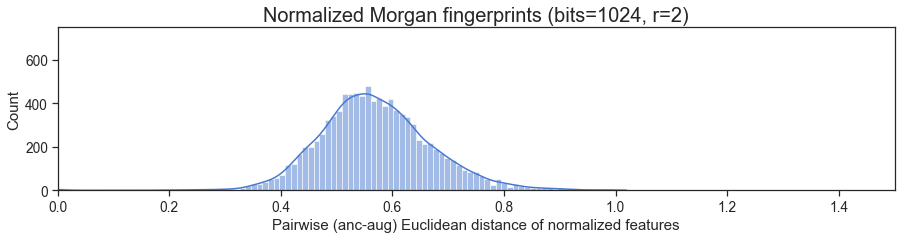

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='ticks',font_scale=1.25,palette='muted')

bns = 100
ylim = 750

t = f'Normalized Morgan fingerprints (bits=1024, r=2)' #, {bns} bins)'

plt.figure(figsize=(15,3))
plt.title(t,fontsize=20)
plt.ylim(0,ylim)
plt.xlim(0,1.5)

sns.histplot(anc_aug_dists, kde=True, bins=bns) #bins=100)

if dist_type=='tanimoto':
    plt.xlabel('Pairwise (anc-aug) Tanimoto distance of descriptors')
elif dist_type=='jaccard':
    plt.xlabel('Pairwise (anc-aug) Jaccard distance of descriptors')
elif dist_type=='euclidean':
    plt.xlabel('Pairwise (anc-aug) Euclidean distance of normalized features')
    
plt.savefig(f'{rdir}plot_figs/{tag}_{bns}bins_ylim{ylim}.png', bbox_inches='tight')
plt.show()

## 5) Calculate and plot UMAP projection.

In [32]:
import umap.umap_ as umap
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import random

def get_umap_coords(tag_emb, df, latents, n_neighs, min_dist, 
                    save_coords=True, save_plot=True, show_plot=True):
 
    rdir = '/home/kat/Repos/SALSA/results/'
    
    pt = str(min_dist).split('.')[1]
    tag_coords = '_'.join([tag_emb, f'{n_neighs}neigh', f'mindist0pt{pt}'])
    print(f"Tag is {tag_coords}!")
    
    umapper = umap.UMAP(n_neighbors=n_neighs, min_dist=min_dist, 
                        n_components=2, metric='euclidean')
    embedding = umapper.fit_transform(latents)

    df['x'] = embedding[:, 0]
    df['y'] = embedding[:, 1]

    if save_coords:
        csv_out = f'{rdir}umap_dfs/{tag_coords}.csv'
        df.to_csv(csv_out,index=False)
        print(f"Saved smiles and coords to {csv_out}!")
        
    sns.set_theme(style='ticks',font_scale=1.5)
    plt.figure(figsize=(10,10))
    sns.scatterplot(data=df[df['Atype']=='Aug'], x='x', y='y', hue='Atype', 
                    alpha=0.5, s=10, palette={'Aug':'red'})
    sns.scatterplot(data=df[df['Atype']=='Anc'], x='x', y='y', hue='Atype', 
                    alpha=1., s=7, palette={'Anc':'blue'})
        
    if save_plot:
        png_out = f'{rdir}umap_figs/{tag_coords}.png'
        plt.savefig(png_out, bbox_inches='tight')
        print(f"Saved umap plot to {png_out}!")
    if show_plot:
        plt.show()
        
    return df

Tag is 2022050220_baseline_2000n_test_morgan_bitv_1024b_2r_eucnorm_32neigh_mindist0pt1!
Saved smiles and coords to /home/kat/Repos/SALSA/results/umap_dfs/2022050220_baseline_2000n_test_morgan_bitv_1024b_2r_eucnorm_32neigh_mindist0pt1.csv!
Saved umap plot to /home/kat/Repos/SALSA/results/umap_figs/2022050220_baseline_2000n_test_morgan_bitv_1024b_2r_eucnorm_32neigh_mindist0pt1.png!


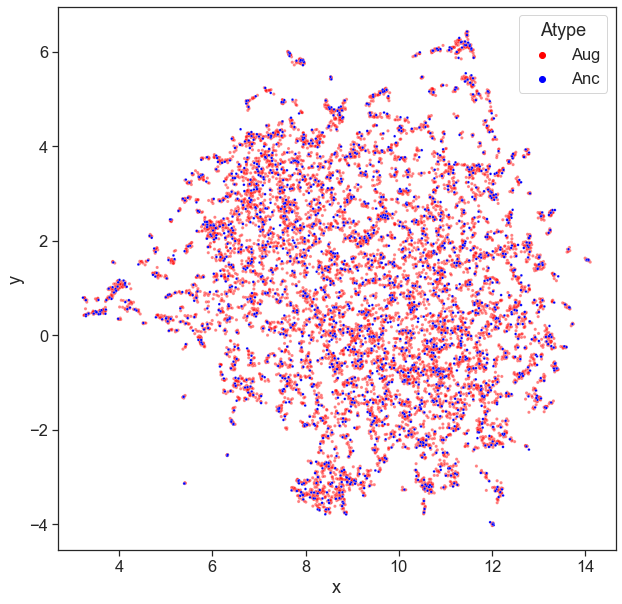

,Smiles,Atype,Label,x,y
0,CC(C)CC(NC(=O)C(CC(C)C)NC(=O)C1NC(=O)NC(=O)C1F...,Anc,0,5.059561,1.591577
1,O=C(Nc1cccc(C(F)(F)F)c1)c1nscc1NCCc1ccc2c(c1)OCO2,Anc,1,8.817772,1.502002
2,c1ccc(-c2nnc(N3CCOCC3)c3ccccc23)cc1,Anc,2,8.598592,4.656032
3,NC1(C(=O)O)CCc2cc(N(CCCl)CCCl)ccc2C1,Anc,3,6.790143,0.224916
4,Cc1ncoc1-c1nnc(SCCCNC2CC3CC3(c3ccccc3)C2)n1C,Anc,4,8.536960,5.471522
...,...,...,...,...,...
11995,CC(Cn1nnc2ccccc2c1=O)C(=O)NCC1CCC(C(=O)O)CC1,Aug,1999,10.545501,3.432962
11996,Cc1ccc2c(=O)n(CCC(=O)NCC3CCC(C(=O)O)CC3)nnc2c1,Aug,1999,10.478088,3.385973
11997,NC1(CNC(=O)CCn2nnc3ccccc3c2=O)CCC(C(=O)O)CC1,Aug,1999,10.488128,3.434285
11998,CC(NC(=O)CCn1nnc2ccccc2c1=O)C1CCC(C(=O)O)CC1,Aug,1999,10.655381,3.446043


In [33]:
get_umap_coords(tag_emb=tag, df=df, latents=fps, n_neighs=32, min_dist=0.1, 
               save_coords=True, save_plot=True, show_plot=True)